Predict the next three numbers:
- Reuse the model from ex2 (that can predict only one following number)
- The only difference from ex2 is the last section (Section 6) of inferencing

# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: NVIDIA L4 (UUID: GPU-800d1871-4356-1bbf-84c2-cd1fbed03d96)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: NVIDIA L4


In [3]:
# Set fixed seeding values for reproducability during experiments
# Skip this cell if random initialization (with varied results) is needed

# https://keras.io/examples/keras_recipes/reproducibility_recipes/
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
#keras.utils.set_random_seed(1234)

# 2. Create the deep RNN model

In [4]:
my_rnn = keras.models.Sequential()
my_rnn.add( keras.layers.Input(shape=(None,1)) )

# batch_size=None, time_steps=None, input_dim=1
## RNN layer 1
my_rnn.add( keras.layers.SimpleRNN( units=20, return_sequences=True ) )
## RNN layer 2
my_rnn.add( keras.layers.SimpleRNN( units=20, return_sequences=True ) )
## RNN layer 3
my_rnn.add( keras.layers.SimpleRNN( units=10 ) )

# Use the default linear activation
my_rnn.add( keras.layers.Dense(1) )

my_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581 (6.18 KB)

 Trainable params: 1,581 (6.18 KB)

 Non-trainable params: 0 (0.00 B)

# 3. Create train/val/test sets

- Generate a 1D time series from `start_val` to `stop_val` with step 2:

In [5]:
start_val , stop_val = -4000 , 2000

# Create raw data
series = np.arange(start_val, stop_val+1, 2)
n_data = series.shape[0]

# Preview
print(f"{type(series)=} , {series.shape=} , {series}")

type(series)=<class 'numpy.ndarray'> , series.shape=(3001,) , [-4000 -3998 -3996 ...  1996  1998  2000]


- <u>Split the data from oldest to newest</u>: first 80% for training, next 10% for validation, last 10% for testing.
- Compute the training statistics (mean and SD) <u>using only the training portion</u>.
- Normalize the entire 1D sequence (z-score) using the training statistics.

In [6]:
# Split ratios
n_train = int(n_data * 0.8)         # 80% train
n_test = int(n_data * 0.1)          # 10% test
n_val = n_data - n_train - n_test   # 10% validation

# Compute training's mean and SD
train_mean = np.mean(series[:n_train])
train_std = np.std(series[:n_train])

# Normalize entire series using training stats
series_norm = (series - train_mean) / train_std
print(f"{type(series_norm)=} , {series_norm.shape=} , {series_norm}")

type(series_norm)=<class 'numpy.ndarray'> , series_norm.shape=(3001,) , [-1.73132927 -1.72988589 -1.72844252 ...  2.59591137  2.59735475
  2.59879812]


- Split the normalized 1D sequence (`series_norm`) into input sequences `X_norm` (each containing `n_input_timesteps`=5 consecutive values) and targets `Y_norm` (the next value following each sequence). The unnormalized versions (`X` and `Y`) are kept only for reference.

In [7]:
# Sliding window parameters
n_input_timesteps = 5  # number of timesteps for input sequence

# Generate sliding windows
X, Y = [], []
X_norm, Y_norm = [], []
for i in range(len(series_norm) - n_input_timesteps):
    X.append(series[i:i+n_input_timesteps])
    Y.append(series[i+n_input_timesteps])

    X_norm.append(series_norm[i:i+n_input_timesteps])
    Y_norm.append(series_norm[i+n_input_timesteps])

X = np.array(X)
Y = np.array(Y)
X_norm = np.array(X_norm)
Y_norm = np.array(Y_norm)

# Preview
print(f"{type(X)=} , {X.shape=} , {X}")
print(f"{type(Y)=} , {Y.shape=} , {Y}\n")
print(f"{type(X_norm)=} , {X_norm.shape=} , {X_norm}")
print(f"{type(Y_norm)=} , {Y_norm.shape=} , {Y_norm}")

type(X)=<class 'numpy.ndarray'> , X.shape=(2996, 5) , [[-4000 -3998 -3996 -3994 -3992]
 [-3998 -3996 -3994 -3992 -3990]
 [-3996 -3994 -3992 -3990 -3988]
 ...
 [ 1986  1988  1990  1992  1994]
 [ 1988  1990  1992  1994  1996]
 [ 1990  1992  1994  1996  1998]]
type(Y)=<class 'numpy.ndarray'> , Y.shape=(2996,) , [-3990 -3988 -3986 ...  1996  1998  2000]

type(X_norm)=<class 'numpy.ndarray'> , X_norm.shape=(2996, 5) , [[-1.73132927 -1.72988589 -1.72844252 -1.72699914 -1.72555577]
 [-1.72988589 -1.72844252 -1.72699914 -1.72555577 -1.72411239]
 [-1.72844252 -1.72699914 -1.72555577 -1.72411239 -1.72266902]
 ...
 [ 2.58869449  2.59013787  2.59158125  2.59302462  2.594468  ]
 [ 2.59013787  2.59158125  2.59302462  2.594468    2.59591137]
 [ 2.59158125  2.59302462  2.594468    2.59591137  2.59735475]]
type(Y_norm)=<class 'numpy.ndarray'> , Y_norm.shape=(2996,) , [-1.72411239 -1.72266902 -1.72122564 ...  2.59591137  2.59735475
  2.59879812]


- Divide `X_norm` and `Y_norm` into training, validation, and test sets. The unnormalized versions are kept only for reference.
- Reshape `X_norm` into `(batch_size, time_steps, input_dim)` as required by the SimpleRNN layer

In [8]:
# Split indices
train_end = n_train - n_input_timesteps
val_end = train_end + n_val

# Split into train/val/test
x_train = X[:train_end].reshape(-1, n_input_timesteps, 1)
y_train = Y[:train_end]
x_train_norm = X_norm[:train_end].reshape(-1, n_input_timesteps, 1)
y_train_norm = Y_norm[:train_end]

x_val = X[train_end:val_end].reshape(-1, n_input_timesteps, 1)
y_val = Y[train_end:val_end]
x_val_norm = X_norm[train_end:val_end].reshape(-1, n_input_timesteps, 1)
y_val_norm = Y_norm[train_end:val_end]

x_test = X[val_end:].reshape(-1, n_input_timesteps, 1)
y_test = Y[val_end:]
x_test_norm = X_norm[val_end:].reshape(-1, n_input_timesteps, 1)
y_test_norm = Y_norm[val_end:]

# Preview shapes
print(f"x_train shape: {x_train.shape}, y_train_norm shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}, y_val_norm shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}, y_test_norm shape: {y_test.shape}")
print(f"x_train_norm shape: {x_train_norm.shape}, y_train_norm shape: {y_train_norm.shape}")
print(f"x_val_norm shape: {x_val_norm.shape}, y_val_norm shape: {y_val_norm.shape}")
print(f"x_test_norm shape: {x_test_norm.shape}, y_test_norm shape: {y_test_norm.shape}")

# Preview first sample
print("\nFirst x_train sample:", x_train[0].ravel())
print("First y_train sample:", y_train[0])
print("First x_train_norm sample:", x_train_norm[0].ravel())
print("First y_train_norm sample:", y_train_norm[0])

x_train shape: (2395, 5, 1), y_train_norm shape: (2395,)
x_val shape: (301, 5, 1), y_val_norm shape: (301,)
x_test shape: (300, 5, 1), y_test_norm shape: (300,)
x_train_norm shape: (2395, 5, 1), y_train_norm shape: (2395,)
x_val_norm shape: (301, 5, 1), y_val_norm shape: (301,)
x_test_norm shape: (300, 5, 1), y_test_norm shape: (300,)

First x_train sample: [-4000 -3998 -3996 -3994 -3992]
First y_train sample: -3990
First x_train_norm sample: [-1.73132927 -1.72988589 -1.72844252 -1.72699914 -1.72555577]
First y_train_norm sample: -1.7241123910300602


# 4. Compile and train the model

In [9]:
@keras.saving.register_keras_serializable(package="Custom", name="mae_denorm")
def mae_denorm(y_true, y_pred):
    # y_true and y_pred are normalized
    y_true_denorm = (y_true * train_std) + train_mean
    y_pred_denorm = (y_pred * train_std) + train_mean
    return torch.mean(torch.abs(y_true_denorm - y_pred_denorm))

In [10]:
adam = keras.optimizers.Adam(learning_rate=0.001)

# For regression, the loss can be used as the evaluation metric as well
my_rnn.compile( loss="mse", optimizer=adam, metrics=['mae',mae_denorm] )

In [11]:
checkpoint_filepath = "RNN_ex3_bestmodel_epoch{epoch:03d}.keras"
model_checkpoint_callback = keras.callbacks.ModelCheckpoint( filepath=checkpoint_filepath,
                                                              save_weights_only=False,
                                                              monitor='val_loss',
                                                              mode='min',
                                                              save_best_only=True)

In [12]:
hist = my_rnn.fit ( x_train_norm, y_train_norm,
                    validation_data=(x_val_norm,y_val_norm),
                    batch_size=64, epochs=300,
                    callbacks=[model_checkpoint_callback] )

Epoch 1/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0896 - mae: 0.2081 - mae_denorm: 1499.4967 - val_loss: 0.0243 - val_mae: 0.1361 - val_mae_denorm: 199.1482
Epoch 2/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 9.9633e-04 - mae: 0.0253 - mae_denorm: 1559.8171 - val_loss: 0.0293 - val_mae: 0.1581 - val_mae_denorm: 227.5600
Epoch 3/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.1756e-04 - mae: 0.0149 - mae_denorm: 1571.7560 - val_loss: 0.0230 - val_mae: 0.1390 - val_mae_denorm: 200.5603
Epoch 4/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.1064e-04 - mae: 0.0123 - mae_denorm: 1601.1007 - val_loss: 0.0198 - val_mae: 0.1290 - val_mae_denorm: 186.1490
Epoch 5/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.4032e-04 - mae: 0.0097 - mae_denorm: 1548.8989 - val_loss: 0.0166 - val_mae: 0.1177 - val_mae_denorm: 170.2764
Epoch 6/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.0403e-04 - mae: 0.0081 - mae_denorm: 1577.4532 - val_loss: 0.0139 - val_mae: 

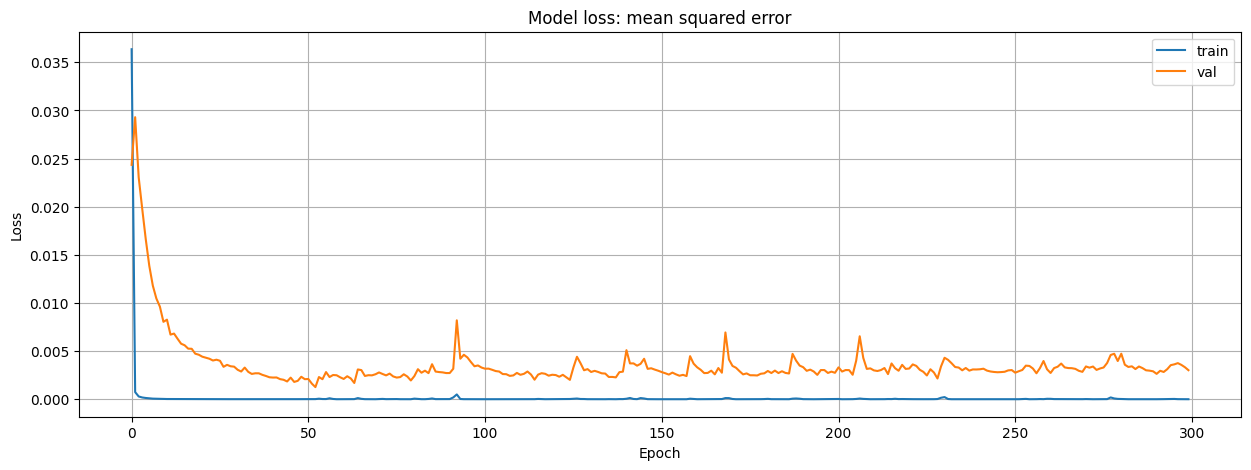

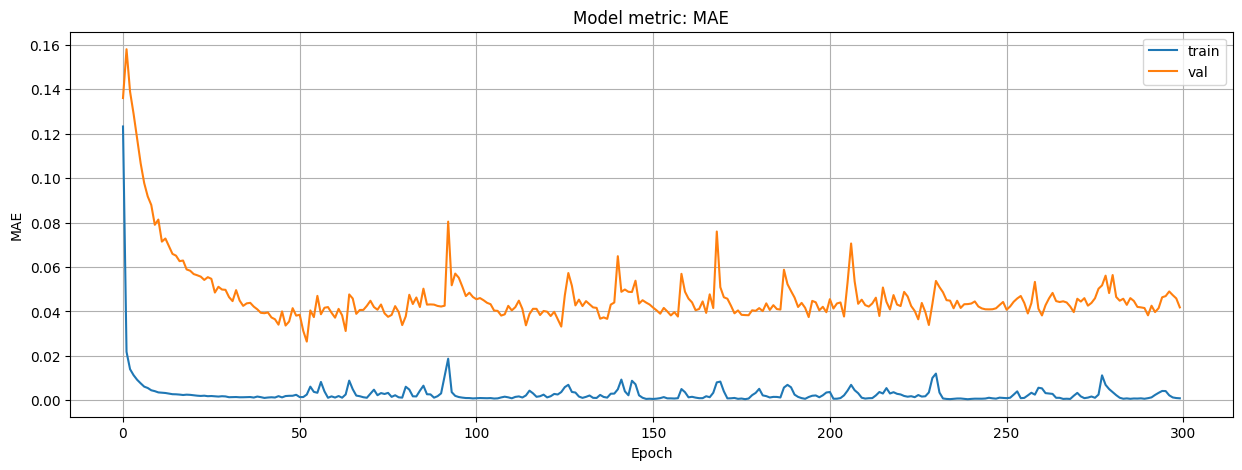

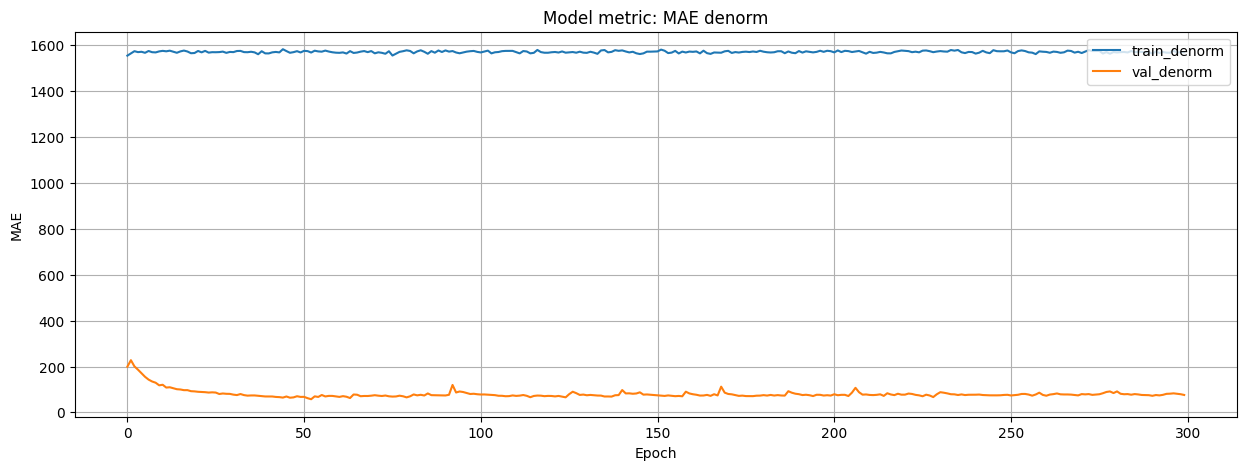

In [13]:
# Plot training & validation loss values
plt.figure(figsize=(15,5))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss: mean squared error')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# Plot training & validation mae values
plt.figure(figsize=(15,5))
plt.plot(hist.history['mae'])
plt.plot(hist.history['val_mae'])
plt.title('Model metric: MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# Plot training & validation mae_denorm values
plt.figure(figsize=(15,5))
plt.plot(hist.history['mae_denorm'])
plt.plot(hist.history['val_mae_denorm'])
plt.title('Model metric: MAE denorm')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['train_denorm', 'val_denorm'], loc='upper right')
plt.grid()
plt.show()

# 5. Evaluate the model

In [14]:
# Load the model from the best epoch (minimum val_loss)
import os
bestmodel_path = max( [ f for f in os.listdir(".") if f.startswith('RNN_ex3_bestmodel_') and f.endswith(".keras") ] )
print( f"The best model: {bestmodel_path}" )

my_rnn_best = keras.models.load_model(bestmodel_path, compile=True)

The best model: RNN_ex3_bestmodel_epoch053.keras


In [15]:
# Evaluate the model from the last epoch
score = my_rnn.evaluate( x_test_norm, y_test_norm, verbose=0, return_dict=True )
print( "Test results (model from the last epoch):", score )

# Evaluate the model from the best epoch
score = my_rnn_best.evaluate( x_test_norm, y_test_norm, verbose=0, return_dict=True )
print( "Test results (model from the best epoch):", score )

Test results (model from the last epoch): {'loss': 0.08964337408542633, 'mae': 0.2814532518386841, 'mae_denorm': 405.78851318359375}
Test results (model from the best epoch): {'loss': 0.041934750974178314, 'mae': 0.1916043907403946, 'mae_denorm': 276.87139892578125}


# 6. Inference

In [16]:
# How many steps ahead to predict numbers
n_steps = 3

# Show results for the first 20 data in the test set
for i in range( 20 ):
    # Deep copy
    x_norm = np.copy( x_test_norm[i] ).reshape(1,-1,1)

    # Predict n_steps ahead
    for step in range( n_steps ):
        y_pred_norm = my_rnn_best.predict( x_norm, verbose=0 )

        # Concatenate y_pred_norm to the end of x_norm
        x_norm = np.concatenate( [ x_norm, y_pred_norm.reshape(1,1,1) ], axis=1 )

    # Denormalize using training statistics
    x = ( x_norm.reshape(1,-1) * train_std ) + train_mean

    print( f"======= x_test[{i}] and its {n_steps}-step-ahead numbers =======" )
    print( f"Original x_test: {x_test[i].reshape(-1,)}" )
    print( f"Original y_test: {y_test[i]}" )
    print( f"Predicted y_test: { x[ 0, -n_steps: ] }" )
    print( f"Predicted y_test with rounding: {np.around(x[ 0, -n_steps: ])}\n" )

======= x_test[0] and its 3-step-ahead numbers =======
Original x_test: [1392 1394 1396 1398 1400]
Original y_test: 1402
Predicted y_test: [ 1289.85045282  -788.2983911  -2024.99785778]
Predicted y_test with rounding: [ 1290.  -788. -2025.]

======= x_test[1] and its 3-step-ahead numbers =======
Original x_test: [1394 1396 1398 1400 1402]
Original y_test: 1404
Predicted y_test: [ 1291.08270475  -788.03393596 -2025.73733282]
Predicted y_test with rounding: [ 1291.  -788. -2026.]

======= x_test[2] and its 3-step-ahead numbers =======
Original x_test: [1396 1398 1400 1402 1404]
Original y_test: 1406
Predicted y_test: [ 1292.31330485  -787.76972859 -2026.47387589]
Predicted y_test with rounding: [ 1292.  -788. -2026.]

======= x_test[3] and its 3-step-ahead numbers =======
Original x_test: [1398 1400 1402 1404 1406]
Original y_test: 1408
Predicted y_test: [ 1293.54060134  -787.50593418 -2027.20860197]
Predicted y_test with rounding: [ 1294.  -788. -2027.]

======= x_test[4] and its 3-step